In [ ]:
65. Which payment method is most common?

66. Which payment method generates the most revenue? ----------> "JOINS"

67. What is the average payment value by payment method?

68. How are installment counts distributed?

69. Is there a relationship between installments and order value? ---------> "not clear"

Useful visualization:

Bar chart
Pie/donut chart
Boxplot

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
folder_path = "C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data"
data = {}
for file in os.listdir(folder_path):
    # print(file.split(".")[0])
    data[file.split(".")[0].replace("olist_","").replace("_dataset","").replace("order_","")] = folder_path + "/" + file
data

{'customers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_customers_dataset.csv',
 'geolocation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_geolocation_dataset.csv',
 'orders': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_orders_dataset.csv',
 'items': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_items_dataset.csv',
 'payments': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_payments_dataset.csv',
 'reviews': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_order_reviews_dataset.csv',
 'products': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_products_dataset.csv',
 'sellers': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/olist_sellers_dataset.csv',
 'product_category_name_translation': 'C:/Users/nagal/OneDrive/Documents/Learn/Repo/Olist-Project/data/product_category_name_transla

In [ ]:
65. Which payment method is most common?
I used value_counts() to count each payment type and identify the most common payment method.
I then created a bar chart to visualize the distribution of payment methods.

Most common payment method: credit_card
Number of payments: 76795


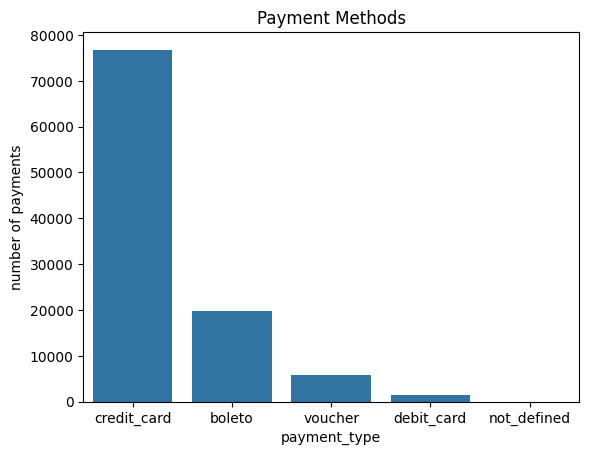

In [20]:
df_payments = pd.read_csv(data["payments"])
payment_types = df_payments["payment_type"].value_counts().reset_index(name="number of payments")
#print("Most common payment method:",df_payments["payment_type"].value_counts().idxmax()
#print("Number of payments:",df_payments["payment_type"].value_counts().max())

print("Most common payment method:",payment_types.iloc[0]["payment_type"])
print("Number of payments:",payment_types.iloc[0]["number of payments"])

sns.barplot(data=payment_types,x="payment_type",y="number of payments")
plt.title("Payment Methods")
plt.show()

In [22]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
66. Which payment method generates the most revenue?
“I grouped the payments by payment type and calculated the total payment value for each method. Then I sorted the results in descending order to identify which payment method generated the highest revenue. I also visualized the results using a bar chart.”

In [70]:
df_items = pd.read_csv(data["items"])
df_payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

payment method generating the highest revenue: credit_card with 12542084.19 amount


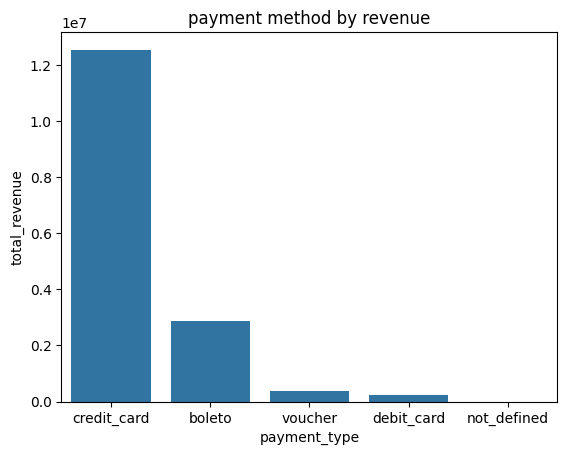

In [68]:
payments_revenue = df_payments.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False).reset_index(name="total_revenue")
print("payment method generating the highest revenue:",payments_revenue.iloc[0]["payment_type"],"with",payments_revenue.iloc[0]["total_revenue"],"amount")
plt.title("payment method by revenue")
sns.barplot(data=payments_revenue,x="payment_type",y="total_revenue")
plt.show()


In [69]:
payments_revenue

,payment_type,total_revenue
0,credit_card,12542084.19
1,boleto,2869361.27
2,voucher,379436.87
3,debit_card,217989.79
4,not_defined,0.00


In [ ]:
67. What is the average payment value by payment method?


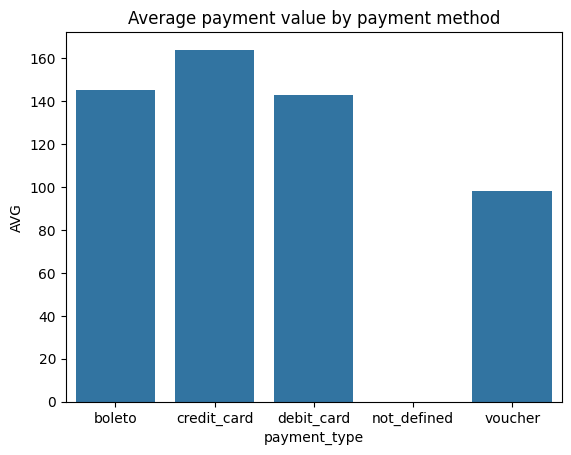

In [128]:
payment_type_value = df_payments.groupby(["payment_type","order_id"])["payment_value"].sum().reset_index(name="payment_type_value")
avearage_payment_value = payment_type_value.groupby("payment_type")["payment_type_value"].mean().reset_index(name="AVG")
plt.title("Average payment value by payment method")
sns.barplot(data=avearage_payment_value,x="payment_type",y="AVG")
plt.show()

In [125]:
payment_type_value

,payment_type,order_id,payment_type_value
0,boleto,00048cc3ae777c65dbb7d2a0634bc1ea,34.59
1,boleto,0008288aa423d2a3f00fcb17cd7d8719,126.54
2,boleto,0009792311464db532ff765bf7b182ae,127.55
3,boleto,000c3e6612759851cc3cbb4b83257986,112.71
4,boleto,0010dedd556712d7bb69a19cb7bbd37a,111.12
...,...,...,...
101681,voucher,ff20ee702706d9e407a34de9fe2ff768,50.00
101682,voucher,ff7400d904161b62b6e830b3988f5cbd,100.00
101683,voucher,ff978de32e717acd3b5abe1fb069d2b6,49.14
101684,voucher,ffa1dd97810de91a03abd7bd76d2fed1,418.73


In [71]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
68. How are installment counts distributed?
I used value_counts() to calculate the number of payments for each installment count. 
Then I sorted the installment counts in ascending order to understand the distribution.

In [75]:
df_payments["payment_installments"].value_counts()
installment_distribution = (df_payments["payment_installments"].value_counts().sort_index().reset_index(name="payment_count"))
print(installment_distribution)

    payment_installments  payment_count
0                      0              2
1                      1          52546
2                      2          12413
3                      3          10461
4                      4           7098
5                      5           5239
6                      6           3920
7                      7           1626
8                      8           4268
9                      9            644
10                    10           5328
11                    11             23
12                    12            133
13                    13             16
14                    14             15
15                    15             74
16                    16              5
17                    17              8
18                    18             27
19                    20             17
20                    21              3
21                    22              1
22                    23              1
23                    24             18


In [ ]:
69. Is there a relationship between installments and order value

In [77]:
df_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


                           order_id  order_value  payment_installments
0  00010242fe8c5a6d1ba2dd792cb16214        58.90                     2
1  00018f77f2f0320c557190d7a144bdd3       239.90                     3
2  000229ec398224ef6ca0657da4fc703e       199.00                     5
3  00024acbcdf0a6daa1e931b038114c75        12.99                     2
4  00042b26cf59d7ce69dfabb4e55b4fd9       199.90                     3
Correlation:
                      payment_installments  order_value
payment_installments              1.000000     0.313135
order_value                       0.313135     1.000000


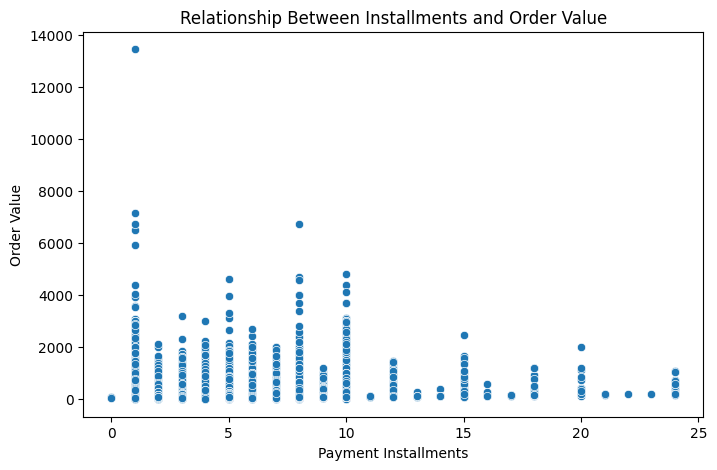

In [121]:
# Step 1: Calculate total order value for each order
order_value = (
    df_items.groupby("order_id")["price"]
    .sum()
    .reset_index(name="order_value")
)

# Step 2: Check how many different installment values each order has
payment_check = (
    df_payments.groupby("order_id")["payment_installments"]
    .nunique()
)

# Step 3: Keep only orders that have one unique installment value
single_installment_orders = payment_check[
    payment_check == 1
].index

# Step 4: Get the installment value for those orders
order_installments = (
    df_payments[
        df_payments["order_id"].isin(single_installment_orders)
    ]
    .groupby("order_id")["payment_installments"]
    .first()
    .reset_index()
)

# Step 5: Merge order value with installment information
order_value_installments = pd.merge(
    order_value,
    order_installments,
    on="order_id",
    how="inner"
)

# Step 6: Check the resulting data
print(order_value_installments.head())

# Step 7: Calculate correlation
correlation = order_value_installments[
    ["payment_installments", "order_value"]
].corr()

print("Correlation:")
print(correlation)

# Step 8: Create scatter plot
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=order_value_installments,
    x="payment_installments",
    y="order_value"
)

plt.title("Relationship Between Installments and Order Value")
plt.xlabel("Payment Installments")
plt.ylabel("Order Value")

plt.show()

correlation:                     total_installments  order_value
total_installments            1.000000     0.316089
order_value                   0.316089     1.000000


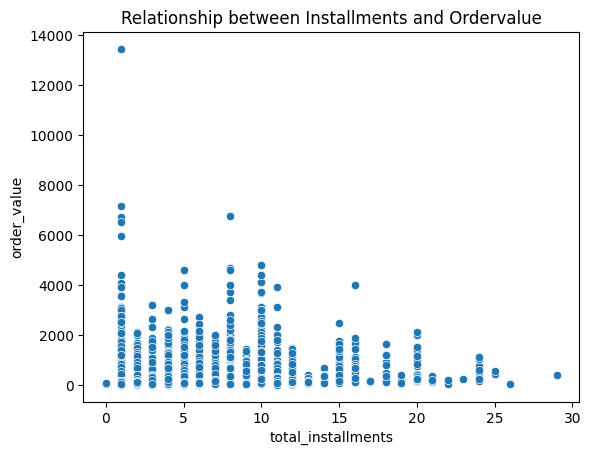

In [120]:
order_value = df_items.groupby("order_id")["price"].sum().reset_index(name="order_value")
order_payment = pd.merge(
    order_value,
    df_payments[["order_id", "payment_installments"]],
    on="order_id",
    how="inner"
)
order_value_installments = order_payment.groupby(["order_id","order_value"])["payment_installments"].sum().reset_index(name="total_installments").sort_values("total_installments",ascending=False)
print("correlation:",order_value_installments[["total_installments","order_value"]].corr())
plt.title("Relationship between Installments and Ordervalue")
sns.scatterplot(data=order_value_installments,x="total_installments",y="order_value")
plt.show()

In [79]:
items_payments = pd.merge(df_items,df_payments,on="order_id",how="inner")
items_payments.groupby("payment_installments")["price"].sum()

payment_installments
0         129.28
1     5342623.69
2     1342053.05
3     1273163.21
4     1005395.35
5      838244.54
6      721787.06
7      265336.11
8     1202462.49
9      109785.12
10    1999470.24
11       2159.15
12      36983.94
13       1984.89
14       2286.09
15      30100.83
16       1298.80
17       1048.22
18      12307.87
20       9543.06
21        554.80
22        209.99
23        216.00
24       9971.56
Name: price, dtype: float64

In [108]:
df_payments.groupby("order_id")["payment_installments"].nunique().sort_values(ascending=False)

order_id
1d251ab94983c4adb11e4b168abb1439    3
1d3b8d78074e0b50f10346941e67e9de    3
19018a1b097164d2fadb3018902f3221    2
fbf352b18a26c6a86a53cca922facd25    2
fbe3a31675cc6b48eff1c765ae6bfb06    2
                                   ..
55b853b7f8c102926b63840137c88ff6    1
55b8090225e782a06895d20d302d5630    1
55b7d8a3d0db6bec3060f8434a82a307    1
55b6cfcdaae4a8dc9629850dc635995d    1
fffe41c64501cc87c801fd61db3f6244    1
Name: payment_installments, Length: 99440, dtype: int64

In [105]:
df_payments[df_payments["payment_installments"] >4]
df_payments[df_payments.duplicated(
    subset=["payment_installments", "order_id"]
)]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
1456,683bf306149bb869980b68d48a1bd6ab,1,credit_card,1,8.58
2324,e6a66a8350bb88497954d37688ab123e,2,voucher,1,10.51
2393,8e5148bee82a7e42c5f9ba76161dc51a,1,credit_card,1,0.67
2414,816ccd9d21435796e8ffa9802b2a782f,1,credit_card,1,5.65
2707,1be51feefcd481bee3118900e6777057,3,voucher,1,8.77
...,...,...,...,...,...
103769,573131fe2b7df5e3ce4d88bf7702f6d0,1,credit_card,1,15.53
103771,c1deab56eafcb4bec7703bbe7bd25137,1,credit_card,1,8.70
103778,fd86c80924b4be8fb7f58c4ecc680dae,1,credit_card,1,76.10
103860,31bc09fdbd701a7a4f9b55b5955b8687,6,voucher,1,77.99


In [109]:
df_payments[df_payments["order_id"] == "1d251ab94983c4adb11e4b168abb1439"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
15259,1d251ab94983c4adb11e4b168abb1439,2,credit_card,4,65.96
32551,1d251ab94983c4adb11e4b168abb1439,3,voucher,1,53.89
93089,1d251ab94983c4adb11e4b168abb1439,1,credit_card,6,118.56


In [110]:
df_items = pd.read_csv(data["items"])

df_items[df_items["order_id"] == "1d251ab94983c4adb11e4b168abb1439"]


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
12852,1d251ab94983c4adb11e4b168abb1439,1,fb92dc4602bd9224e0e267496748afc5,8ae520247981aa06bc94abddf5f46d34,2018-03-14 00:49:38,219.0,19.41


In [90]:
df_payments["payment_sequential"].value_counts()

payment_sequential
1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
18        6
19        6
16        6
17        6
21        4
20        4
22        3
26        2
24        2
23        2
25        2
29        1
28        1
27        1
Name: count, dtype: int64